In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# NewAthena 2026 projects w/ Isobel Romero-Shaw and others

Useful information on NewAthena from https://www.eoportal.org/satellite-missions/newathena#h.1fob9te:

- NewAthena carries two instruments, the Wide Field Imager (WFI), an array of silicone active pixel sensors with an integrated detector/amplifier structure, and the X-ray Integral Field Unit (X-IFU), an X-ray spectrometer consisting of a microcalorimeter array.

- WFI has a field of view (FoV) of 40’ x 40’, with a spectral resolution of 170 eV at 6 keV. X-IFU has a spectral resolution of 4 eV, up to 7 keV, over a 4’ equivalent diameter field-of-view (over the hexagonal shape), covered with ~1500 pixels of 5” size.

- Both instruments operate in an energy range between about 0.2 keV and 12.0 keV

- The instruments will be placed in the focal plane of an X-ray telescope enabling an angular resolution of 9” on-axis (Half-Energy Width).

- NewAthena will operate from the First Lagrange point, L1, a gravitationally semi-stable point 1.5 million km from Earth.

**Step 1: Using Blandford-Znajek jet luminosity equation, calculate BBH and AGN parameters required to launch jets visible by NewAthena.**

In [2]:
# Constants:

G = 6.67430e-8               # Gravitational constant (cm^3 g^-1 s^-2)
c = 2.99792458e10            # Speed of light (cm/s)
pi = np.pi                   # Pi
k_B = 1.380649e-16           # Boltzmann constant (erg/K)
m_p = 1.6726219e-24          # Proton mass (g)
M_sun = 1.989e33             # Mass of the Sun (g)
M_AGN = 1e8 * M_sun          # Typical mass of an AGN
R = 1e4                      # Gravitational radii. See https://arxiv.org/abs/1206.2309 for reference
f = 0.1                      # Jet conversion efficiency. See https://arxiv.org/abs/2311.10518 for reference
d_L_Mpc = np.array([100, 500, 1000, 3000])    # Typical distance of AGN from us (Mpc)
Mpc_to_cm = 3.085677581e24   # Conversion of Mpc to cm
d_L = d_L_Mpc * Mpc_to_cm    # Typical distance of AGN from us (cm)



def blanford_znajek(M_binary, rho_AGN, v_k, c_s, f):# Returns luminosity in erg/s (f dimensionless, Mdot [g/s], c**2 [cm^2/s^2])
    Mdot = (4 * pi * G**2 * M_binary**2 * rho_AGN) / ((v_k**2 + c_s**2)**1.5)
    L_j = f * Mdot * c**2
    
    return L_j


def sound_speed(T, gamma=5/3, mu=0.6):
    return np.sqrt(gamma * k_B * T / (mu * m_p))  # cm/s


def gravitational_radius(M):
    return G * M / c**2  # cm


def orbital_radius(R, M_AGN):
    return R * gravitational_radius(M_AGN)


def keplerian_velocity(M_AGN, r):
    return np.sqrt(G * M_AGN / r)  # cm/s


def xray_flux(L,d):
    return L/(4*np.pi*(d**2))


def eddington_luminosity(M):  # erg/s. M must be in solar masses.    
    return 1.26e38 * M




def disk_height(r, H_over_R=0.01):
    return H_over_R * r


def t_BHL(M_binary, v_kick, c_s):      # Bondi-Hoyle timescale (seconds). M_binary in grams. v_kick and c_s in cm/s
    r_BHL = G * M_binary / (v_kick**2 + c_s**2)
    return r_BHL / v_kick


def t_breakout(H, beta_h):   # Jet breakout time (seconds)
    return H / (beta_h * c)

 
def t_diffusion(rho_AGN, beta_h, kappa=0.34):      # Equation (15) from Chen & Dai (2023)
    return 1.0 / (kappa * rho_AGN * beta_h**2 * c)


def total_delay(M_binary, rho_AGN, T, r, v_kick):
    c_s = sound_speed(T)
    H = disk_height(r)
    t_bhl = t_BHL(M_binary, v_kick, c_s)
    beta_h = 0.3  # can be changed if necessary
    t_bre = t_breakout(H, beta_h)
    t_diff = t_diffusion(rho_AGN, beta_h)
    t_kick = 0
    return t_bhl+t_bre+t_diff+t_kick

In [3]:
r = orbital_radius(R, M_AGN)
v_k = keplerian_velocity(M_AGN, r)
print(v_k)

v_kick = 300 * 1e5      # 300 km/s -> cm/s

299792458.0


In [4]:
# Establish parameter space (for M_binary, rho_AGN, T (influences c_s))

N = 100 # Use for now, increase for more accuracy, reduce if computations taking too long

M_vals = np.logspace(2, 6, N)  # in solar masses. See arXiv:2406.01687 for reference on values
rho_vals = np.logspace(-14,-10,N) # in units of g/cm^3. See https://arxiv.org/abs/2009.03936 Appendix for reference
T_vals = np.logspace(4,5,N) # See https://arxiv.org/abs/1806.04680 for reference


r = orbital_radius(R, M_AGN)
v_k = keplerian_velocity(M_AGN, r)


results_dict = []
L_j_list = []

c_s_vals = sound_speed(T_vals)

for M in M_vals:
    M_cgs = M * M_sun
    for rho in rho_vals:
        for T, c_s in zip(T_vals, c_s_vals):
            L_j = blanford_znajek(M_cgs,rho,v_k,c_s,f) # L_j in g cm^-2 s^-3 or erg s^-1
            #L_Edd = 1.3e38 * M     # M in solar masses
            #L_j = min(L_j, L_Edd)  # Apply luminosity limit to not consider unphysical parameters just in case
            L_j_list.append(L_j)
            delay_sec = total_delay(M_cgs,rho,T,r,v_kick)
            delay_days = delay_sec / 86400  # Converts seconds to days
            
            results_dict.append({
                "M": M,
                "rho": rho,
                "T": T,
                "L_j": L_j,
                "delay_days": delay_days
                })

In [5]:
print(L_j_list[0:20]) # Printing a small sample just to see
print(type(L_j_list))
print("Min L_j:", np.min(L_j_list))
print("Max L_j:", np.max(L_j_list))

print(results_dict[0]) # This is a list of dictionaries to see which M, rho and T values give each L_j value

[7.386752628851771e+37, 7.386745977409987e+37, 7.386739169463316e+37, 7.386732201329535e+37, 7.38672506923979e+37, 7.386717769336571e+37, 7.386710297671618e+37, 7.386702650203801e+37, 7.386694822796913e+37, 7.386686811217459e+37, 7.386678611132352e+37, 7.386670218106574e+37, 7.38666162760078e+37, 7.386652834968851e+37, 7.386643835455372e+37, 7.3866346241930685e+37, 7.386625196200177e+37, 7.386615546377745e+37, 7.386605669506888e+37, 7.386595560245959e+37]
<class 'list'>
Min L_j: 7.384209354483855e+37
Max L_j: 7.386752628851771e+49
{'M': 100.0, 'rho': 1e-14, 'T': 10000.0, 'L_j': 7.386752628851771e+37, 'delay_days': 8.838699483148842}


In [6]:
delay_list = np.array([entry["delay_days"] for entry in results_dict])

print("Minimum delay (days):", delay_list.min())
print("Maximum delay (days):", delay_list.max())
print("Median delay (days):", np.median(delay_list))

Minimum delay (days): 7.450244768265324
Maximum delay (days): 56765.19982483774
Median delay (days): 564.1183814380834


In [7]:
# epsilon_X_vals = np.logspace(-4, -2, 5)

K_X_vals = np.array([10, 30, 50, 70, 90, 110, 130, 150, 170, 200]) # X-ray bolometric correction factor

# Convert L_j from list to NumPy array
L_j_array = np.array(L_j_list)

# Convert jet luminosity to X-ray luminosity
# Shape: (K_X, L_j)

L_X_grid = np.array([L_j_array / K_X for K_X in K_X_vals])

print("Shape of L_X_grid:", L_X_grid.shape)
print("K_X values:", K_X_vals)

print("Min L_X:", np.min(L_X_grid))
print("Max L_X:", np.max(L_X_grid))

print("Sample values:")
print(L_X_grid[0, :10])

Shape of L_X_grid: (10, 1000000)
K_X values: [ 10  30  50  70  90 110 130 150 170 200]
Min L_X: 3.692104677241928e+35
Max L_X: 7.386752628851771e+48
Sample values:
[7.38675263e+36 7.38674598e+36 7.38673917e+36 7.38673220e+36
 7.38672507e+36 7.38671777e+36 7.38671030e+36 7.38670265e+36
 7.38669482e+36 7.38668681e+36]


In [8]:
# Luminosity to Flux conversion

L_X_grid = np.array([L_j_array / K_X for K_X in K_X_vals])

# Now broadcast over distances:
F_X_grid = xray_flux(
    L_X_grid[None, :, :],      # (1, K_X, N)
    d_L[:, None, None]         # (4, 1, 1)
)

print("Flux grid shape:", F_X_grid.shape)
print("K_X values:", K_X_vals)

for i, d in enumerate(d_L):
    print(f"\nDistance = {d} cm")
    print("Min flux:", np.min(F_X_grid[i]))
    print("Max flux:", np.max(F_X_grid[i]))

Flux grid shape: (4, 10, 1000000)
K_X values: [ 10  30  50  70  90 110 130 150 170 200]

Distance = 3.0856775810000004e+26 cm
Min flux: 3.085766437923875e-19
Max flux: 6.173658479364714e-06

Distance = 1.5428387905000002e+27 cm
Min flux: 1.2343065751695502e-20
Max flux: 2.469463391745886e-07

Distance = 3.0856775810000004e+27 cm
Min flux: 3.0857664379238755e-21
Max flux: 6.173658479364715e-08

Distance = 9.257032743000001e+27 cm
Min flux: 3.4286293754709726e-22
Max flux: 6.8596205326274615e-09


In [9]:
F_limit = 1e-16  # erg/cm^2/s  Use for now

detectable = F_X_grid > F_limit  # These are the detections by NewAthena

for i, d in enumerate(d_L_Mpc):
    frac = np.sum(detectable[i]) / detectable[i].size
    print(f"Distance = {d} Mpc → Detectable fraction = {frac:.4f}")

Distance = 100 Mpc → Detectable fraction = 0.9267
Distance = 500 Mpc → Detectable fraction = 0.8046
Distance = 1000 Mpc → Detectable fraction = 0.7345
Distance = 3000 Mpc → Detectable fraction = 0.6180


In [10]:
# Extract detectable parameter sets

detected_params_per_distance = []

for i, d in enumerate(d_L_Mpc):
    
    # Collapse over epsilon_X (detectable if ANY epsilon_X works)
    detectable_any_eps = np.any(detectable[i], axis=0)
    
    # Indices of detectable systems
    detected_indices = np.where(detectable_any_eps)[0]
    
    # Extract parameter dictionaries
    detected_params = [results_dict[j] for j in detected_indices]
    
    detected_params_per_distance.append({
        "distance_Mpc": d,
        "params": detected_params
    })
    
    print(f"Distance = {d} Mpc → {len(detected_params)} detectable systems")

Distance = 100 Mpc → 976000 detectable systems
Distance = 500 Mpc → 891100 detectable systems
Distance = 1000 Mpc → 836000 detectable systems
Distance = 3000 Mpc → 725000 detectable systems


In [11]:
# Extract ranges of detectable parameters

for entry in detected_params_per_distance:
    
    d = entry["distance_Mpc"]
    params = entry["params"]
    
    if len(params) == 0:
        print(f"\nDistance = {d} Mpc → No detectable systems")
        continue
    
    M_detected   = np.array([p["M"] for p in params])
    rho_detected = np.array([p["rho"] for p in params])
    T_detected   = np.array([p["T"] for p in params])
    
    print(f"\nDistance = {d} Mpc")
    print(f"M range:   {M_detected.min():.2e} – {M_detected.max():.2e} Msun")
    print(f"rho range: {rho_detected.min():.2e} – {rho_detected.max():.2e} g/cm^3")
    print(f"T range:   {T_detected.min():.2e} – {T_detected.max():.2e} K")


Distance = 100 Mpc
M range:   1.00e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 500 Mpc
M range:   1.00e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 1000 Mpc
M range:   1.00e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 3000 Mpc
M range:   1.32e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K


In [12]:
print(np.shape(M_detected))

(725000,)


In [13]:
print("Fraction at lowest rho:",
      np.sum(rho_detected == rho_vals.min()) / len(rho_detected))

print("10th percentile:", np.percentile(rho_detected, 10))
print("90th percentile:", np.percentile(rho_detected, 90))

Fraction at lowest rho: 0.006620689655172414
10th percentile: 3.678379771828634e-14
90th percentile: 5.214008287999695e-11


In [14]:
'''
# Example: mass distribution at first distance 
logbins = np.logspace(2,6,101)

for entry in detected_params_per_distance: 
    M_detected = [p["M"] for p in entry["params"]]
    
    plt.figure(figsize=(8,5))
    
    plt.hist(M_detected,bins=logbins, histtype='stepfilled',linewidth=1, alpha=0.35,edgecolor='black') 
    plt.xscale('log') 
    plt.xlabel("BBH Mass ($M_\\odot$)",fontsize=12) 
    plt.ylabel("Count",fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(f"Detected Mass Distribution at "f"{entry['distance_Mpc']} Mpc", fontsize=14)
    plt.grid(True, which="both", alpha=0.3)
    plt.show()
    
'''

'\n# Example: mass distribution at first distance \nlogbins = np.logspace(2,6,101)\n\nfor entry in detected_params_per_distance: \n    M_detected = [p["M"] for p in entry["params"]]\n    \n    plt.figure(figsize=(8,5))\n    \n    plt.hist(M_detected,bins=logbins, histtype=\'stepfilled\',linewidth=1, alpha=0.35,edgecolor=\'black\') \n    plt.xscale(\'log\') \n    plt.xlabel("BBH Mass ($M_\\odot$)",fontsize=12) \n    plt.ylabel("Count",fontsize=12)\n    plt.xticks(fontsize=12)\n    plt.yticks(fontsize=12)\n    plt.title(f"Detected Mass Distribution at "f"{entry[\'distance_Mpc\']} Mpc", fontsize=14)\n    plt.grid(True, which="both", alpha=0.3)\n    plt.show()\n    \n'

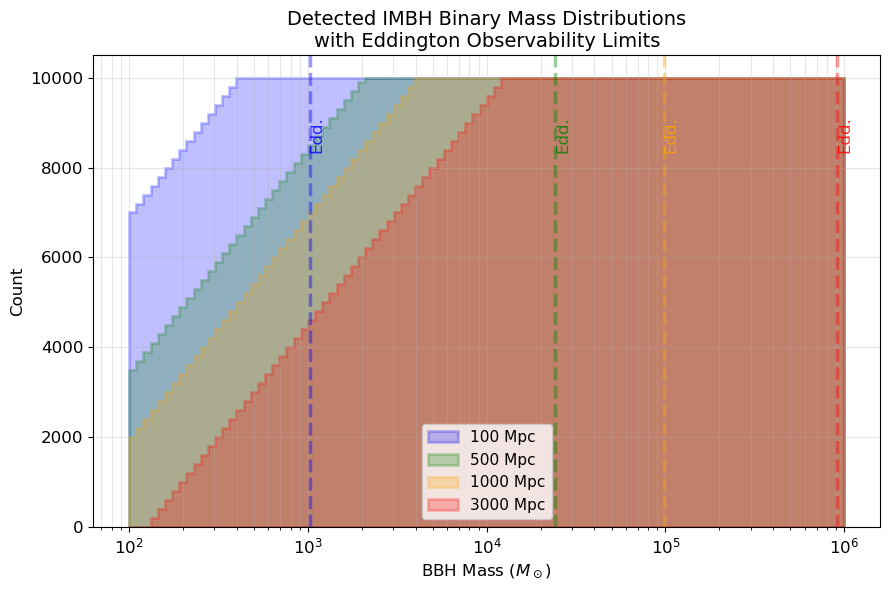

In [15]:
# Overlaid detected mass distributions with Eddington limits

logbins = np.logspace(2,6,101)

colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(9,6))

# Average epsilon_X value (middle of my episolon_X range set above)
epsilon_X_rep = 1e-3


# Precompute Eddington luminosities (to save on computation time)
L_Edd_vals = eddington_luminosity(M_vals)
L_X_Edd_vals = epsilon_X_rep * L_Edd_vals  # Convert to X-ray luminosities


# Loop to plot histograms
for entry, color, d_cm in zip(detected_params_per_distance,colors,d_L):

    M_detected = [p["M"] for p in entry["params"]]

    plt.hist(M_detected,bins=logbins,histtype='stepfilled',alpha=0.25,linewidth=2,edgecolor=color,color=color,
            label=f"{entry['distance_Mpc']} Mpc")

    # Fluxes for all masses simultaneously
    F_Edd_vals = xray_flux(L_X_Edd_vals, d_cm)

    # Detectable masses
    detectable_Edd = F_Edd_vals > F_limit

    observable_masses = M_vals[detectable_Edd]

    # Minimum observable mass
    if len(observable_masses) > 0:
        M_limit = np.min(observable_masses)
        plt.axvline(M_limit,color=color,linestyle='--',linewidth=2.5,alpha=0.4)
        plt.text(M_limit,plt.ylim()[1]*0.8,"Edd.",rotation=90,color=color,fontsize=12,alpha=0.8) # Text label

        
# Plot formatting
plt.xscale('log')
plt.xlabel("BBH Mass ($M_\\odot$)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Detected IMBH Binary Mass Distributions\n""with Eddington Observability Limits",fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# NEXT STEPS:

- Figure out expected time offset between jet detection and merger of IMBH binary (merger happens before jet, so detecting the merger with GW detectors lets us have enough time hopefully to point NewAthena in that direction). Check Fig 1 of Word doc proposal (Tagawa et al. 2023 Fig 19), they migth have an estimate there for this time.

- Write code to calculate function of time delay (with all parts) and how it varies with system parameters


- bilby will give us uncertainties on mass and distance estimations needed for Hubble constant calculation (check out Hubble constant measurements with GW events)

- 

 